# 03 - champion replay, $1000 account

Replay the archived champion exactly from `strategies/volume_weighted_breakout/runs`: use `best_strategy.py` plus `best.json` symbols, params, timeframe, and period. Equity and benchmark are rebased to `$1000` for display. This does not edit the live `strategy.py` and does not write iteration artifacts.

In [1]:
import json
import sys; sys.path.insert(0, ".")   # cwd = notebooks/volume_weighted_breakout
from _lab import *

best = json.loads(BEST_JSON.read_text(encoding="utf-8"))
symbols = list(best["symbols"])
params = dict(best["params"])
tf = best["tf"]
start, end = best["period"]
initial_cash = 1000.0

print("best iter:", best["iter"])
print("composite:", best["composite"])
print("strategy file:", BEST_STRATEGY_FILE)
print("period:", start, "->", end)
print("tf:", tf)
print("symbols:", symbols)
print("params:")
print(json.dumps(params, indent=2))

best iter: 42
composite: 0.45906086257001544
strategy file: C:\Users\digbi\Projects\research-lab\strategies\volume_weighted_breakout\runs\best_strategy.py
period: 2024-01-01 -> 2026-01-01
tf: 4h
symbols: ['BTCUSDT', 'ETHUSDT', 'SOLUSDT', 'AVAXUSDT']
params:
{
  "breakout_lookback": 8,
  "volume_ma": 20,
  "volume_mult": 1.9,
  "flat_trend_span": 60,
  "flat_slope_bars": 12,
  "flat_slope_abs": 0.005,
  "atr_period": 14,
  "exhaustion_bars": 6,
  "max_prior_move": 0.08,
  "follow_volume_mult": 1.2,
  "follow_bars": 3,
  "take_atr": 2.5,
  "max_hold_bars": 30
}


In [2]:
result = run_strategy_file(
    BEST_STRATEGY_FILE,
    symbols=symbols,
    start=start,
    end=end,
    params=params,
    tf=tf,
    return_curves=True,
)
metrics_frame(result)

,sharpe,sortino,max_dd,total_return,n_trades,pct_time_in_position,profit_factor
split,,,,,,,
train,2.256844,2.987076,0.086786,0.976731,379,60.425532,1.488818
oos,0.376976,0.435786,0.114798,0.032848,137,67.062044,1.054225


In [3]:
curves = result["curves"]
equity = rebase(curves["equity"], initial_cash)
benchmark = rebase(curves["benchmark"], initial_cash)
raw_equity = rebase(curves["raw_equity"], initial_cash)
dd = drawdown(equity)
cutoff = curves["split_cutoff"]

summary = pd.Series({
    "start_equity": equity.iloc[0],
    "end_equity": equity.iloc[-1],
    "total_return": equity.iloc[-1] / equity.iloc[0] - 1.0,
    "max_drawdown": dd.min(),
    "benchmark_end": benchmark.iloc[-1],
    "bars": len(equity),
})
summary

start_equity     1000.000000
end_equity       2039.424881
total_return        1.039425
max_drawdown       -0.114798
benchmark_end    1224.605327
bars             4386.000000
dtype: float64

[saved] notebooks\volume_weighted_breakout\_out\03_champion_replay_1000_equity_drawdown.png


WindowsPath('C:/Users/digbi/Projects/research-lab/notebooks/volume_weighted_breakout/_out/03_champion_replay_1000_equity_drawdown.png')

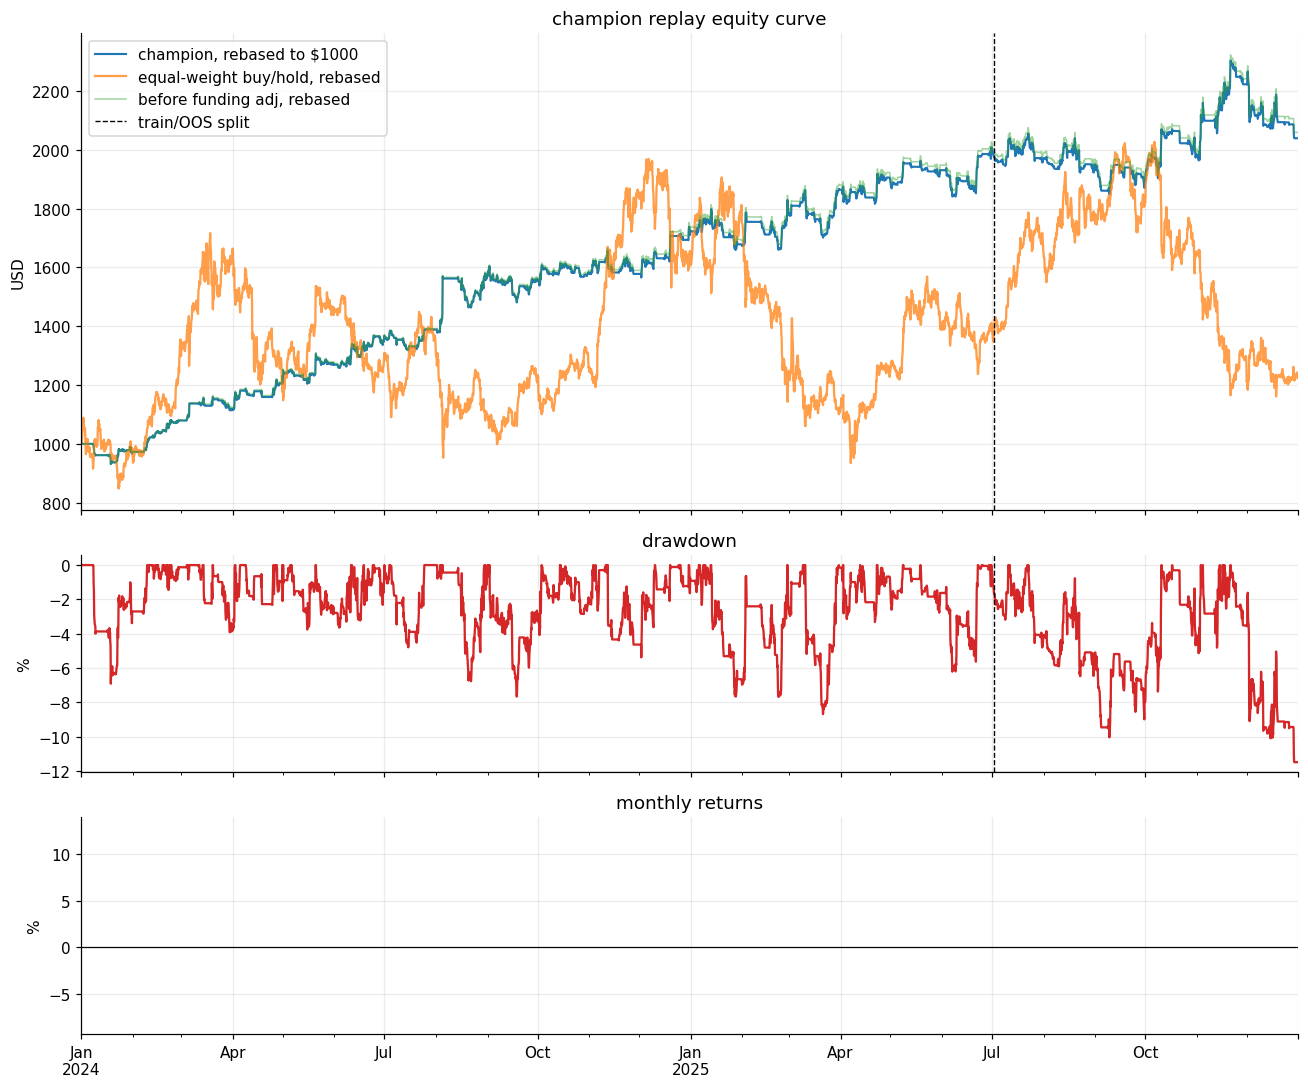

In [4]:
fig, ax = plt.subplots(3, 1, figsize=(12, 10), sharex=True, gridspec_kw={"height_ratios": [2.2, 1.0, 1.0]})

equity.plot(ax=ax[0], label="champion, rebased to $1000", lw=1.4)
benchmark.plot(ax=ax[0], label="equal-weight buy/hold, rebased", alpha=0.75)
raw_equity.plot(ax=ax[0], label="before funding adj, rebased", alpha=0.45, lw=1.0)
ax[0].axvline(cutoff, color="k", lw=0.9, ls="--", label="train/OOS split")
ax[0].set_title("champion replay equity curve")
ax[0].set_ylabel("USD")
ax[0].legend(loc="best")

(dd * 100).plot(ax=ax[1], color="C3")
ax[1].axvline(cutoff, color="k", lw=0.9, ls="--")
ax[1].set_title("drawdown")
ax[1].set_ylabel("%")

mret = monthly_returns(equity) * 100
colors = np.where(mret >= 0, "C2", "C3")
ax[2].bar(mret.index, mret.values, width=20, color=colors, alpha=0.8)
ax[2].axhline(0, color="k", lw=0.8)
ax[2].axvline(cutoff, color="k", lw=0.9, ls="--")
ax[2].set_title("monthly returns")
ax[2].set_ylabel("%")

show("03_champion_replay_1000_equity_drawdown")

In [5]:
trades = curves["trades"].copy()
print("trades:", len(trades))
trades.head(10)

trades: 516


,entry_time,exit_time,symbol,direction,size,entry_price,exit_price,pnl_quote,return_pct,duration_hours,slice,entry_notional_usd,entry_daily_volume_usd,participation_pct
0,2024-01-08 16:00:00+00:00,2024-01-08 20:00:00+00:00,BTCUSDT,Long,0.051648,47010.600590,46968.102720,-4.864516,-0.002004,4.0,train,2427.998246,1.041296e+10,0.000023
1,2024-01-18 20:00:00+00:00,2024-01-23 12:00:00+00:00,BTCUSDT,Short,0.067017,41129.499244,39315.310434,118.615923,0.043033,112.0,train,2756.365770,6.392147e+09,0.000043
2,2024-01-26 12:00:00+00:00,2024-01-28 08:00:00+00:00,BTCUSDT,Long,0.059217,41397.763524,42439.658298,58.966907,0.024054,44.0,train,2451.432861,6.695551e+09,0.000037
3,2024-01-29 20:00:00+00:00,2024-01-31 12:00:00+00:00,BTCUSDT,Long,0.057164,43290.326394,43325.032482,-0.739260,-0.000299,40.0,train,2474.630927,4.887711e+09,0.000051
4,2024-02-07 20:00:00+00:00,2024-02-08 04:00:00+00:00,BTCUSDT,Long,0.055177,44322.431800,44492.373013,6.681501,0.002732,8.0,train,2445.560192,4.571545e+09,0.000053
5,2024-02-08 16:00:00+00:00,2024-02-09 12:00:00+00:00,BTCUSDT,Long,0.054132,45253.624910,47116.117196,98.069520,0.040034,20.0,train,2449.648616,6.028805e+09,0.000041
6,2024-02-12 16:00:00+00:00,2024-02-14 12:00:00+00:00,BTCUSDT,Long,0.052740,49547.016142,51569.342601,103.724663,0.039694,44.0,train,2613.115870,9.503901e+09,0.000027
7,2024-02-26 16:00:00+00:00,2024-02-26 20:00:00+00:00,BTCUSDT,Long,0.049115,54543.153770,54509.548500,-4.596373,-0.001716,4.0,train,2678.876772,9.246236e+09,0.000029
8,2024-02-28 12:00:00+00:00,2024-02-28 16:00:00+00:00,BTCUSDT,Long,0.044286,61012.700660,61021.797210,-2.569585,-0.000951,4.0,train,2702.012957,2.740159e+10,0.000010
9,2024-03-04 04:00:00+00:00,2024-03-04 16:00:00+00:00,BTCUSDT,Long,0.042105,64148.214180,67450.256798,135.983398,0.050347,12.0,train,2700.929133,1.803652e+10,0.000015


In [6]:
if len(trades):
    by_symbol = trades.groupby("symbol").agg(
        n=("symbol", "size"),
        pnl_quote=("pnl_quote", "sum"),
        avg_return=("return_pct", "mean"),
        win_rate=("return_pct", lambda s: (s > 0).mean()),
        avg_duration_h=("duration_hours", "mean"),
    ).sort_values("pnl_quote", ascending=False)
    display(by_symbol)
    display(trades.tail(10))
else:
    print("No trades in this period.")

,n,pnl_quote,avg_return,win_rate,avg_duration_h
symbol,,,,,
SOLUSDT,106,3641.855132,0.007936,0.537736,34.415094
AVAXUSDT,91,3109.986618,0.009069,0.582418,38.681319
ETHUSDT,143,3102.923663,0.004511,0.489510,33.790210
BTCUSDT,176,738.443455,0.001402,0.488636,33.295455


,entry_time,exit_time,symbol,direction,size,entry_price,exit_price,pnl_quote,return_pct,duration_hours,slice,entry_notional_usd,entry_daily_volume_usd,participation_pct
506,2025-10-30 16:00:00+00:00,2025-11-03 16:00:00+00:00,AVAXUSDT,Short,380.217349,17.512542,17.011964,183.108651,0.027500,96.0,oos,6658.572348,1.473030e+08,0.004520
507,2025-11-04 20:00:00+00:00,2025-11-05 08:00:00+00:00,AVAXUSDT,Short,338.750367,15.975402,16.547931,-200.003947,-0.036958,12.0,oos,5411.673389,2.240111e+08,0.002416
508,2025-11-12 20:00:00+00:00,2025-11-13 04:00:00+00:00,AVAXUSDT,Short,316.951234,16.802320,17.393760,-193.418887,-0.036319,8.0,oos,5325.515932,7.524980e+07,0.007077
509,2025-11-13 20:00:00+00:00,2025-11-16 20:00:00+00:00,AVAXUSDT,Short,414.265672,15.931283,15.181428,303.550041,0.045994,72.0,oos,6599.783490,1.160287e+08,0.005688
510,2025-11-17 20:00:00+00:00,2025-11-21 08:00:00+00:00,AVAXUSDT,Short,476.829338,14.366817,13.042481,624.294139,0.091131,84.0,oos,6850.519965,1.060410e+08,0.006460
511,2025-12-02 16:00:00+00:00,2025-12-03 20:00:00+00:00,AVAXUSDT,Long,389.056945,13.644654,14.746129,422.461198,0.079581,28.0,oos,5308.547522,7.793838e+07,0.006811
512,2025-12-09 16:00:00+00:00,2025-12-11 04:00:00+00:00,AVAXUSDT,Long,402.898558,14.553509,13.397982,-471.754097,-0.080455,36.0,oos,5863.587757,6.857436e+07,0.008551
513,2025-12-15 16:00:00+00:00,2025-12-17 20:00:00+00:00,AVAXUSDT,Short,480.655090,12.350916,11.877193,221.292324,0.037276,52.0,oos,5936.530616,5.636703e+07,0.010532
514,2025-12-18 20:00:00+00:00,2025-12-19 16:00:00+00:00,AVAXUSDT,Short,480.542725,11.432857,12.284271,-415.409202,-0.075612,20.0,oos,5493.976069,7.258014e+07,0.007570
515,2025-12-23 16:00:00+00:00,2025-12-24 00:00:00+00:00,AVAXUSDT,Short,436.439176,12.105789,12.062258,13.197265,0.002498,8.0,oos,5283.440705,5.387859e+07,0.009806


In [7]:
# Compare replayed single-split metrics to the archived best.json single-split metrics.
archived = pd.DataFrame({
    "archived_train": best["metrics"]["train"],
    "archived_oos": best["metrics"]["oos"],
})
replayed = pd.DataFrame({
    "replayed_train": result["main"]["train"],
    "replayed_oos": result["main"]["oos"],
})
compare = pd.concat([archived, replayed], axis=1)
compare.loc[["sharpe", "sortino", "max_dd", "total_return", "n_trades", "pct_time_in_position", "profit_factor"]]

,archived_train,archived_oos,replayed_train,replayed_oos
sharpe,2.256844,0.425826,2.256844,0.376976
sortino,2.987076,0.491722,2.987076,0.435786
max_dd,0.086786,0.114798,0.086786,0.114798
total_return,0.976731,0.037025,0.976731,0.032848
n_trades,379.000000,135.000000,379.000000,137.000000
pct_time_in_position,60.425532,67.064220,60.425532,67.062044
profit_factor,1.488818,1.067404,1.488818,1.054225


In [8]:
# Full metric payload, excluding the large curve/trade objects already shown above.
print(json.dumps(clean_metrics(result), indent=2, default=str))

{
  "strategy": "vwb_replay_2dlxhh7f",
  "params": {
    "breakout_lookback": 8,
    "volume_ma": 20,
    "volume_mult": 1.9,
    "flat_trend_span": 60,
    "flat_slope_bars": 12,
    "flat_slope_abs": 0.005,
    "atr_period": 14,
    "exhaustion_bars": 6,
    "max_prior_move": 0.08,
    "follow_volume_mult": 1.2,
    "follow_bars": 3,
    "take_atr": 2.5,
    "max_hold_bars": 30
  },
  "symbols": [
    "BTCUSDT",
    "ETHUSDT",
    "SOLUSDT",
    "AVAXUSDT"
  ],
  "tf": "4h",
  "period": [
    "2024-01-01",
    "2026-01-01"
  ],
  "main": {
    "train": {
      "sharpe": 2.2568435467790966,
      "bench_sharpe": 0.6524951504731988,
      "alpha_sharpe": 1.6043483963058978,
      "information_ratio": 0.0613633268786261,
      "sortino": 2.9870759495679926,
      "calmar": 6.6218645976421024,
      "cagr": 0.5746837721615174,
      "max_dd": 0.08678579328942326,
      "total_return": 0.9767306425978108,
      "target_turnover": 1.378870673952641,
      "hit_rate": 0.4770992366412214,
  